Linear Regression RMSE: 0.047315411597638315
Decision Tree RMSE: 0.06388329202538015
Random Forest RMSE: 0.04791254372793315

===== FINAL RESULT =====
Linear Regression RMSE : 0.047315411597638315
Decision Tree RMSE    : 0.06388329202538015
Random Forest RMSE    : 0.04791254372793315
Best Model: Linear Regression


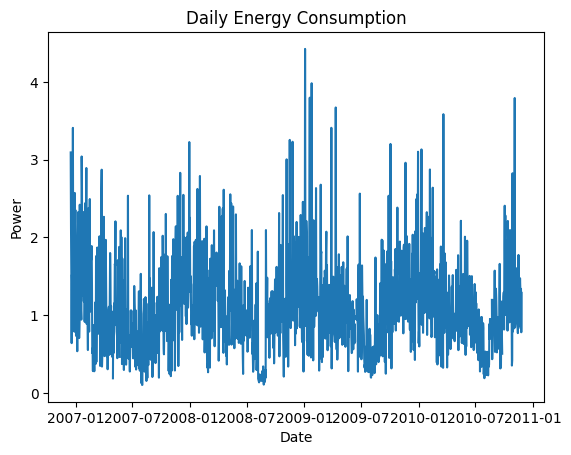

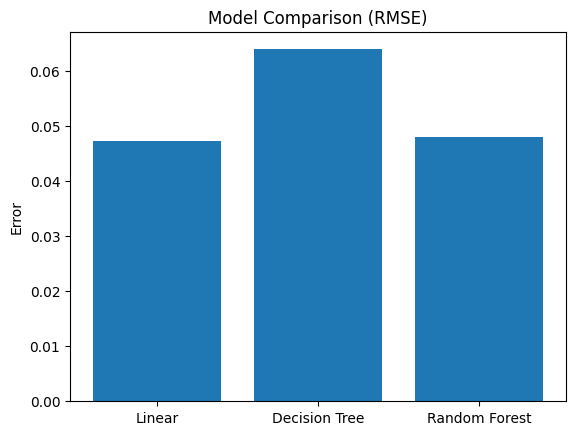

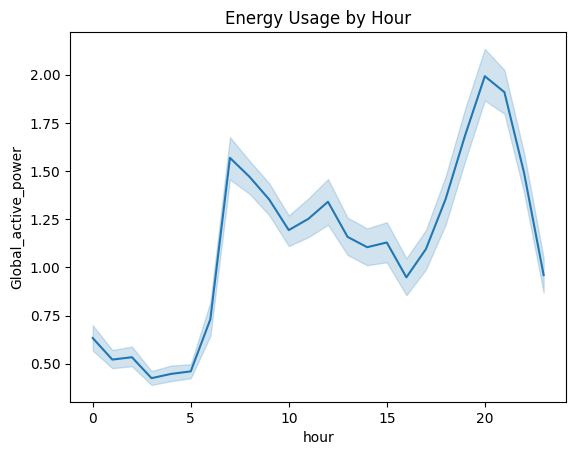

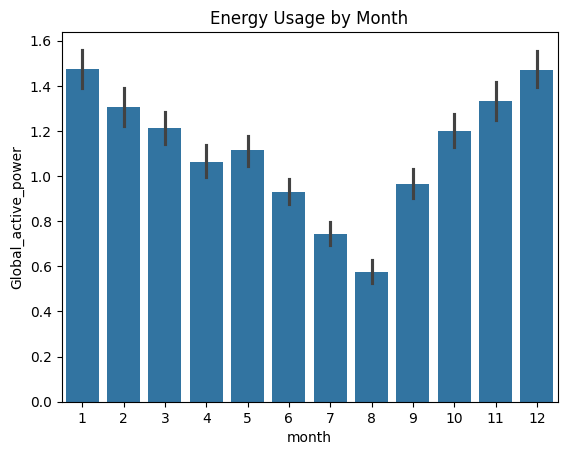

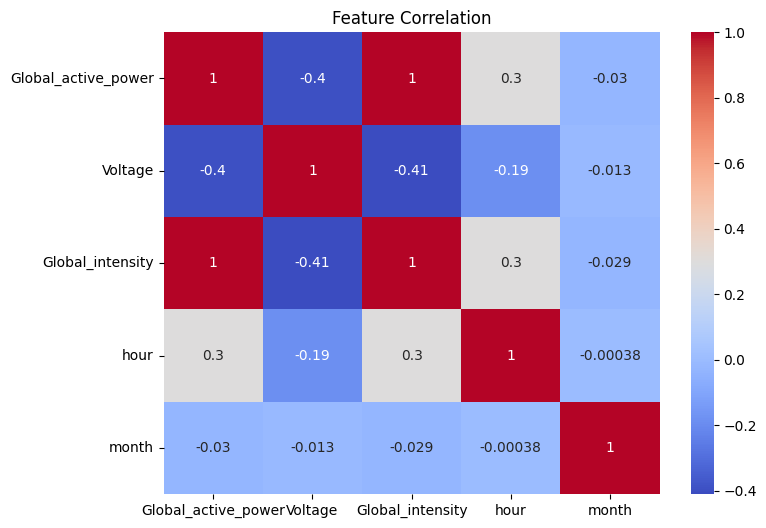


Sample Prediction: 1.5466800000000003


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

df = pd.read_csv(
    "household_power_consumption.txt",
    sep=';',
    na_values=['?']
)

df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    dayfirst=True
)
df = df.dropna()

df['Global_active_power'] = pd.to_numeric(df['Global_active_power'])
df['Voltage'] = pd.to_numeric(df['Voltage'])
df['Global_intensity'] = pd.to_numeric(df['Global_intensity'])

df = df.sample(n=10000, random_state=42)

df['hour'] = df['Datetime'].dt.hour
df['month'] = df['Datetime'].dt.month

X = df[['Voltage', 'Global_intensity', 'hour', 'month']]
y = df['Global_active_power']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression RMSE:", rmse_lr)

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print("Decision Tree RMSE:", rmse_dt)

rf = RandomForestRegressor(n_estimators=50)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest RMSE:", rmse_rf)

print("\n===== FINAL RESULT =====")
print("Linear Regression RMSE :", rmse_lr)
print("Decision Tree RMSE    :", rmse_dt)
print("Random Forest RMSE    :", rmse_rf)

best_model = min(rmse_lr, rmse_dt, rmse_rf)

if best_model == rmse_lr:
    print("Best Model: Linear Regression")
elif best_model == rmse_dt:
    print("Best Model: Decision Tree")
else:
    print("Best Model: Random Forest")

df_daily = df.resample('D', on='Datetime').mean(numeric_only=True)

plt.figure()
plt.plot(df_daily['Global_active_power'])
plt.title("Daily Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Power")
plt.show()

models = ['Linear', 'Decision Tree', 'Random Forest']
rmse_values = [rmse_lr, rmse_dt, rmse_rf]

plt.figure()
plt.bar(models, rmse_values)
plt.title("Model Comparison (RMSE)")
plt.ylabel("Error")
plt.show()

plt.figure()
sns.lineplot(x='hour', y='Global_active_power', data=df)
plt.title("Energy Usage by Hour")
plt.show()

plt.figure()
sns.barplot(x='month', y='Global_active_power', data=df)
plt.title("Energy Usage by Month")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df[['Global_active_power','Voltage','Global_intensity','hour','month']].corr(),
            annot=True, cmap='coolwarm')

plt.title("Feature Correlation")
plt.show()

sample = X.iloc[[0]] 
prediction = rf.predict(sample)

print("\nSample Prediction:", prediction[0])